# 13.2 — Convenciones de devengo: composición contra el SOFR Average real

Entregable de la Fase 0 de M13. Usa `qflib.sofr.compound_sofr` (implementado desde
cero en 13.1... en realidad en el módulo `qflib/sofr.py`, ver el código fuente) sobre
un snapshot **real** de datos del NY Fed — la excepción documentada del currículum al
"sin APIs externas": los datos de mercado de este módulo sí son reales, con snapshot
fechado comiteado en `data/` para que el notebook sea reproducible sin red.

**Recordatorio de las cuatro convenciones** (detalle conceptual en 13.1):

$$R = \left(\prod_i \left(1 + r_i \cdot \frac{n_i}{360}\right) - 1\right) \cdot
\frac{360}{D}$$

la composición base (*in-arrears*, sin convención), donde $i$ recorre los días
hábiles del periodo, $r_i$ el fixing SOFR de ese día, $n_i$ los días calendario que
cubre (1 entre días hábiles consecutivos, 3 si cubre un fin de semana), y
$D=\sum_i n_i$ los días calendario totales del periodo. **Lookback** desplaza sólo la
tasa $X$ días hábiles hacia atrás manteniendo los pesos originales; **observation
shift** desplaza tasa *y* peso juntos (equivale a recalcular la fórmula sobre la
ventana desplazada); **lockout**/**rate cutoff** congelan la tasa de los últimos $X$
días hábiles en el valor observado $X$ días antes del fin — mismo mecanismo, dos
nombres de mercado.

## 0. Configuración y carga del snapshot

In [1]:
import csv
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt

from qflib.sofr import compound_sofr
from qflib.plotting import apply_style

apply_style()

DATA_DIR = Path("..") / ".." / "data"


def latest_snapshot(prefix: str) -> Path:
    candidates = sorted(DATA_DIR.glob(f"{prefix}_*.csv"))
    assert candidates, f"no hay snapshot {prefix}_*.csv en data/ — correr tools/fetch_sofr_data.py"
    return candidates[-1]


sofr_path = latest_snapshot("sofr")
sofrai_path = latest_snapshot("sofrai")

with sofr_path.open() as f:
    _rows = list(csv.DictReader(f))
sofr_dates = [date.fromisoformat(r["date"]) for r in _rows]
sofr_rates = [float(r["sofr"]) for r in _rows]

with sofrai_path.open() as f:
    sofrai_rows = {date.fromisoformat(r["date"]): r for r in csv.DictReader(f)}

print(f"{sofr_path.name}: {len(sofr_dates)} fixings, "
      f"{sofr_dates[0]} .. {sofr_dates[-1]}")

sofr_2026-08-05.csv: 400 fixings, 2024-12-26 .. 2026-08-04


## 1. Entregable 1 — composición base vs SOFR Average publicado

`period_end` se fija en el último `date` del snapshot menos 5 días hábiles (margen
para evitar el borde exacto de la serie descargada). `period_start` es 90 días
calendario antes. El **SOFR Average de 90 días** que publica el NY Fed es, por
definición, exactamente la misma composición base *in-arrears* sin ninguna
convención, sobre una ventana rodante de 90 días calendario terminando en esa fecha —
así que `compound_sofr` sin parámetros de convención debe coincidir con el
`average_90d` publicado, dentro de la tolerancia de redondeo de la fuente (el NY Fed
publica `percentRate`/`average90day` ya redondeados).

In [2]:
period_end = sofr_dates[-6]
period_start = period_end - timedelta(days=90)
published_90d = float(sofrai_rows[period_end]["average_90d"])

r_base_90d = compound_sofr(sofr_dates, sofr_rates, period_start, period_end)

print(f"periodo: [{period_start}, {period_end})")
print(f"compound_sofr (base):      {r_base_90d:.6%}")
print(f"SOFR Average 90d publicado: {published_90d:.6%}")
print(f"diferencia: {(r_base_90d - published_90d) * 1e4:.3f} bp")

periodo: [2026-04-29, 2026-07-28)
compound_sofr (base):      3.625177%
SOFR Average 90d publicado: 3.625180%
diferencia: -0.000 bp


## 2. Entregable 2 — lookback puro vs observation shift

Mismo `period_start`/`period_end`, ahora con `lookback=5` días hábiles: una vez con
`observation_shift=False` (lookback puro) y otra con `observation_shift=True`. Las
tres variantes (base, lookback puro, observation shift) usan las mismas tasas
fuente pero producen resultados distintos — el punto pedagógico central de este
notebook.

Base (in-arrears)        3.625177%
Lookback 5d              3.624954%
Observation shift 5d     3.626747%


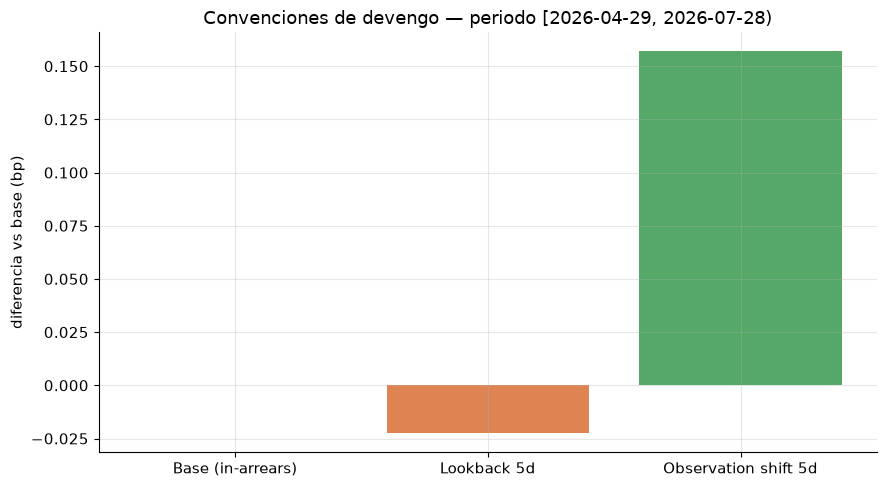

In [3]:
r_lookback = compound_sofr(
    sofr_dates, sofr_rates, period_start, period_end, lookback=5,
)
r_shift = compound_sofr(
    sofr_dates, sofr_rates, period_start, period_end,
    lookback=5, observation_shift=True,
)

variants = {"Base (in-arrears)": r_base_90d, "Lookback 5d": r_lookback,
            "Observation shift 5d": r_shift}
for name, r in variants.items():
    print(f"{name:24s} {r:.6%}")

fig, ax = plt.subplots()
names = list(variants.keys())
bps = [1e4 * (v - r_base_90d) for v in variants.values()]
ax.bar(names, bps, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("diferencia vs base (bp)")
ax.set_title(f"Convenciones de devengo — periodo [{period_start}, {period_end})")
fig.tight_layout()

## 3. Por qué lookback-sin-shift no es replicable con una curva de descuento única

Una swap con devengo `observation shift` **sí** tiene una interpretación limpia en
términos de curva de forwards: el flujo pagado es exactamente la composición de
SOFR sobre una ventana bien definida (la ventana desplazada), así que existe una
única curva de descuento/forwards consistente con ese devengo — es "la curva
evaluada en la ventana desplazada", punto.

Un swap con **lookback puro** (sin shift) no tiene esa propiedad. La tasa de cada
día se toma de una fecha *fuera* del periodo de pago (X días hábiles antes), pero el
*peso* calendario ($n_i$) sigue siendo el del periodo de pago original — una tasa
observada en una fecha se está ponderando con el número de días que le corresponden
a una fecha *distinta*. No existe una curva de forwards única $f(t)$ tal que
$1+r_i\cdot n_i/360$ sea, para cada $i$, el valor de esa curva evaluada
consistentemente en el mismo punto que genera tanto la tasa como el peso — la tasa
viene de un punto de la curva y el peso de otro. Por eso lookback-sin-shift, a
diferencia de observation shift, no admite una réplica exacta vía un único
instrumento de descuento: el mismatch tasa/peso es una fuente de basis genuina, no
una elección de convención neutral.

## Validación

In [4]:
import pytest

# Entregable 1: compuesto base vs SOFR Average 90d publicado (tolerancia de
# redondeo de la fuente, 0.5bp).
assert abs(r_base_90d - published_90d) < 5e-5

# Entregable 2: lookback puro y observation shift deben diferir (el punto
# pedagógico central del notebook).
assert abs(r_lookback - r_shift) > 1e-6

print("OK: ambos entregables validados.")

OK: ambos entregables validados.


## Referencias

- ARRC — guías de convención de devengo RFR (lookback, lockout, observation shift,
  rate cutoff).
- Federal Reserve Bank of New York — *SOFR Averages and Index* (metodología de
  cálculo de las ventanas rodantes de 30/90/180 días publicadas diariamente).
- Ver 13.1 para el contexto institucional completo y el resto de referencias del
  módulo.